# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior

### Before You Begin — Read This

This is not a tutorial. There is no step-by-step guide telling you what to do next.  
You are given a raw dataset, a business problem, and a skeleton. The rest is your job.

**Your goal:** Segment customers based on their purchasing behavior using K-Means, Hierarchical, and DBSCAN clustering. Then tell a coherent business story about what you found.

**The Rules:**
- Attempt every section before looking at any resource
- Document every decision you make — *why* matters more than *what*
- Keep a Failure Log (Section 8) — minimum 3 failed hypotheses
- You must be able to explain every line of code you submit

**Submission:**
- This notebook (.ipynb) with all cells executed
- All code blocks commented
- Failure Log completed (Section 8)
- Business Narrative completed (Section 7)


## Section 0 — Environment Setup

All libraries you will need are imported below. Do not add new ones without justification in a comment.  
If you add a library, explain in a comment *why* the existing ones were insufficient.


In [ ]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from scipy.cluster.hierarchy import dendrogram, linkage

# Cluster Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


---
## Section 1 — Data Loading & First Look

**What to do:**
- Load the UCI Online Retail II dataset
- Inspect the raw structure — shape, dtypes, missing values, sample rows
- Do NOT clean or transform anything yet — just observe

**Questions to answer in comments:**
- How many rows and columns are there?
- What does one row represent?
- Which columns will be useful for customer-level aggregation?
- What problems do you already see?

> **Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> Download the Excel file and load the sheet for Year 2010-2011


In [ ]:
# Load the dataset
# Hint: use pd.read_excel() with the sheet_name parameter
# YOUR CODE HERE
df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

# ── First Look ──────────────────────────────────────────────────────────────

# Print shape
# YOUR CODE HERE
print(f"Dataset Shape : {df.shape}", end="\n\n")

# Print dtypes
# YOUR CODE HERE
print("\n\nData Types\n")
display(df.dtypes)

# Print first 5 rows
# YOUR CODE HERE
print("\n\nFirst 5 rows\n")
display(df.head())

# Check missing values — which columns have nulls? How many?
# YOUR CODE HERE
print("\n\nMissing values\n")
display(df.isna().sum())

# Print basic descriptive statistics
# YOUR CODE HERE
print("\n\nBasic descriptive statistics\n")
display(df.describe())


Dataset Shape : (541910, 8)



Data Types



,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
Price,float64
Customer ID,float64
Country,object




First 5 rows



,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom




Missing values



,0
Invoice,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
Price,0
Customer ID,135080
Country,0




Basic descriptive statistics



,Quantity,InvoiceDate,Price,Customer ID
count,541910.000000,541910,541910.000000,406830.000000
mean,9.552234,2011-07-04 13:35:22.342307584,4.611138,15287.684160
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.080957,NaN,96.759765,1713.603074


**Your Observations (complete this):**

> What do you notice about the data? What surprises you? What problems are already visible?

_Write here before moving on._

- The dataset has 541,910 rows and 8 columns. One row = one product line item within an invoice (not one transaction and not one customer).
- Customer ID has a lot of missing values and this is a problem, so these rows will have to be dropped.
- Invoice column has some values starting with 'C' which means cancelled orders. These need to be removed before calculating Monetary, otherwise spend would be undercounted/wrong.
- Quantity and Price have negative values in the describe() output, which doesn't make sense for normal purchases. These are probably refunds or data entry errors and need to be filtered out.
- InvoiceDate is not in datetime format yet, it will need to be parsed.
- Columns useful for customer-level aggregation: Customer ID (to group by), Invoice (for Frequency), InvoiceDate (for Recency), Quantity and Price (for Monetary), StockCode (for unique products).

## Section 2 — Data Cleaning

**What to do:**
- Handle missing CustomerIDs
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove rows with negative Quantity or Price
- Parse InvoiceDate to datetime

**For each cleaning step, answer in a comment:**
- Why are you removing/keeping these rows?
- What assumption does this cleaning step encode?
- How many rows did you lose? Does that concern you?

> ⚠️ Do not just clean — justify every decision.


In [ ]:
# Work on a copy — never mutate the original
df_clean = df.copy()

# ── Step 1: Remove rows with missing CustomerID ──────────────────────────────
# Why? Write your reasoning as a comment before the code
# How many rows are you dropping?

# We're building a customer-level matrix, so any row without a
# CustomerID can't be assigned to anyone and is useless for our purpose.
# This assumes that these missing IDs are not recoverable and not worth
# guessing/imputing, since guessing a customer ID could wrongly merge
# unrelated purchases into the same "customer".

# 135,080 rows removed — this is actually a big chunk (~25% of the data),
# which is a bit concerning, but there's no safe way to assign these
# transactions to a real customer, so dropping them is the right call.

# YOUR CODE HERE
rows_before = df_clean.shape[0]
df_clean = df_clean.dropna(subset=["Customer ID"])
print(f"Step 1 — Dropped missing CustomerID: {rows_before - df_clean.shape[0]} rows removed")

# ── Step 2: Remove cancelled transactions ────────────────────────────────────
# Cancelled invoices start with 'C'
# Why remove them? What would happen if you kept them in Monetary calculation?

# These represent returns/cancellations, not actual purchases.
# If kept, they would be counted as negative or duplicate transactions
# and would mess up Monetary (total spend would be understated) and
# Frequency (counting a cancelled order as a real visit).
# This assumes cancelled orders shouldn't count toward customer value at all,
# even though in reality a cancellation still tells us something about
# customer behavior (just not something we're modeling here).

# YOUR CODE HERE
rows_before = df_clean.shape[0]
df_clean = df_clean[~df_clean["Invoice"].astype(str).str.startswith("C")]
print(f"Step 2 — Dropped cancellations: {rows_before - df_clean.shape[0]} rows removed")

# ── Step 3: Remove negative Quantity and Price ───────────────────────────────
# YOUR CODE HERE
rows_before = df_clean.shape[0]
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["Price"] > 0)]
print(f"Step 3 — Dropped negative Quantity/Price: {rows_before - df_clean.shape[0]} rows removed")

# ── Step 4: Parse InvoiceDate to datetime ────────────────────────────────────
# YOUR CODE HERE
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"] )

# ── Step 5: Create TotalPrice column ─────────────────────────────────────────
# TotalPrice = Quantity * Price
# YOUR CODE HERE
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["Price"]

# Summary — print shape before and after, and rows lost at each step
print(f"Original shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")


Step 1 — Dropped missing CustomerID: 135080 rows removed
Step 2 — Dropped cancellations: 8905 rows removed
Step 3 — Dropped negative Quantity/Price: 40 rows removed
Original shape: (541910, 8)
Clean shape: (397885, 9)
Rows removed: 144025


## Section 3 — Feature Engineering: Building the Customer Matrix

This is the hardest section. There is no template for what features to build — you decide.

**Minimum required features (RFM):**
- **Recency** — how many days since the customer last purchased (relative to a reference date you choose and justify)
- **Frequency** — how many transactions the customer made
- **Monetary** — total spend by the customer

**Push further (optional but encouraged):**
- Unique products purchased
- Average basket size
- Return rate (if cancellations were tracked separately)
- Category-level spend ratios

**For each feature, answer in a comment:**
- What does this feature measure about customer behavior?
- What business insight does it capture?
- What are its limitations?

> ⚠️ One row in your final matrix = one customer. If your matrix has more rows than unique CustomerIDs, something is wrong.


In [ ]:
# ── Reference Date ──────────────────────────────────────────────────────────
# Choose a reference date for Recency calculation
# Justify your choice in a comment — why this date?

# I picked Dec 10, 2011, which is 1 day after the last transaction in the
# dataset (last one was Dec 9, 2011). I did this so no customer ends up
# with a Recency of exactly 0, and because it's a standard practice in RFM
# analysis to use "day after the last transaction" instead of today's real
# date, since today's date would make every customer's recency around 14
# years which wouldn't help distinguish anyone.

reference_date = pd.Timestamp("2011-12-10")# YOUR CODE HERE

# ── Recency ──────────────────────────────────────────────────────────────────
# Days since last purchase per customer
# YOUR CODE HERE
recency_df = df_clean.groupby("Customer ID")["InvoiceDate"].max().reset_index()
recency_df.columns = ["Customer ID", "LastPurchaseDate"]
recency_df["Recency"] = (reference_date-recency_df["LastPurchaseDate"]).dt.days


# ── Frequency ────────────────────────────────────────────────────────────────
# Number of unique invoices per customer
# YOUR CODE HERE
frequency_df = df_clean.groupby("Customer ID")["Invoice"].nunique().reset_index()
frequency_df.columns = ["Customer ID","Frequency"]

# ── Monetary ─────────────────────────────────────────────────────────────────
# Total spend per customer
# YOUR CODE HERE
monetary_df = df_clean.groupby("Customer ID")["TotalPrice"].sum().reset_index()
monetary_df.columns = ["Customer ID","Monetary"]


# Optional
unique_products_df = df_clean.groupby("Customer ID")["StockCode"].nunique().reset_index()
unique_products_df.columns = ["Customer ID", "UniqueProducts"]

# ── Combine into customer matrix ─────────────────────────────────────────────
# YOUR CODE HERE
# customer_df should have columns: CustomerID, Recency, Frequency, Monetary
# (+ any extra features you engineered)
customer_df = recency_df[['Customer ID', 'Recency']].merge(frequency_df,on="Customer ID", how="left").merge(monetary_df,on="Customer ID", how="left").merge(unique_products_df,on="Customer ID", how="left")
customer_df["AvgBasketSize"] = customer_df["Monetary"] / customer_df["Frequency"]


# Sanity check
print(f"Customer matrix shape: {customer_df.shape}")
print(f"Unique customers in clean data: {df_clean['Customer ID'].nunique()}")
print("These numbers should match.")
customer_df.head()


Customer matrix shape: (4338, 6)
Unique customers in clean data: 4338
These numbers should match.


,Customer ID,Recency,Frequency,Monetary,UniqueProducts,AvgBasketSize
0,12346.0,325,1,77183.60,1,77183.600000
1,12347.0,2,7,4310.00,103,615.714286
2,12348.0,75,4,1797.24,22,449.310000
3,12349.0,18,1,1757.55,73,1757.550000
4,12350.0,310,1,334.40,17,334.400000


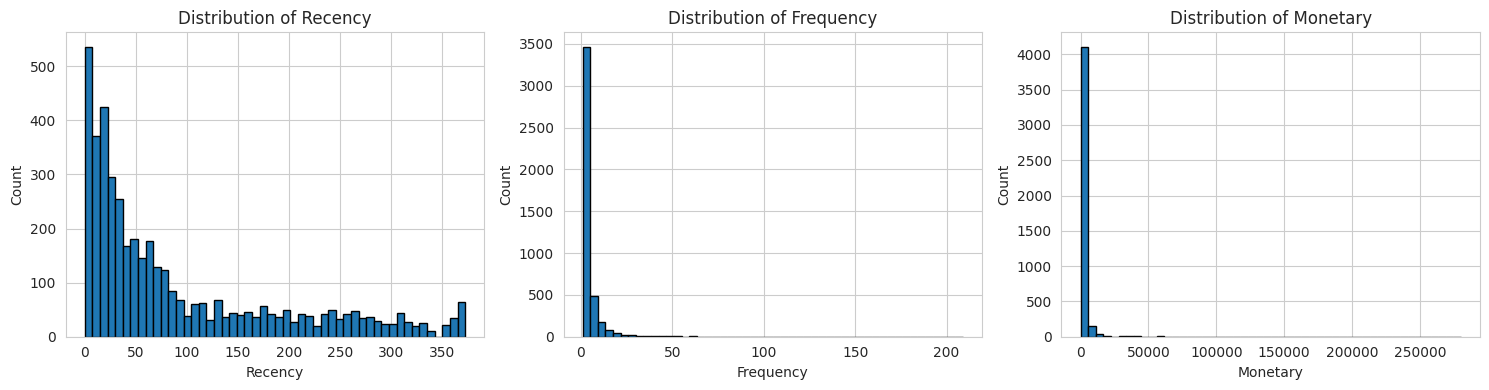

In [ ]:
# ── Distribution Plots ───────────────────────────────────────────────────────
# Plot the distribution of each feature BEFORE handling outliers
# What do you observe? Are there extreme values?

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Recency', 'Frequency', 'Monetary']

for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# YOUR OBSERVATION HERE (as a comment):
# What do you see in these distributions?
# Are there outliers? How will they affect clustering?


# Recency is right-skewed, most customers bought recently (within 50 days)
# but there's a long tail going up to ~370 days of inactive customers.
#
# Frequency is heavily right-skewed, most customers only bought 1-5 times,
# but a few bought 200+ times.
#
# Monetary is also heavily right-skewed, almost everyone is clustered near
# $0-10k but a few outliers go all the way up to $250k.
#
# These outliers (especially in Frequency and Monetary) are a problem for
# clustering because K-Means and Hierarchical clustering use distance and
# a few extreme values will distort the distance calculations and pull
# cluster centers toward themselves. This is why we need to treat outliers
# before scaling and clustering.


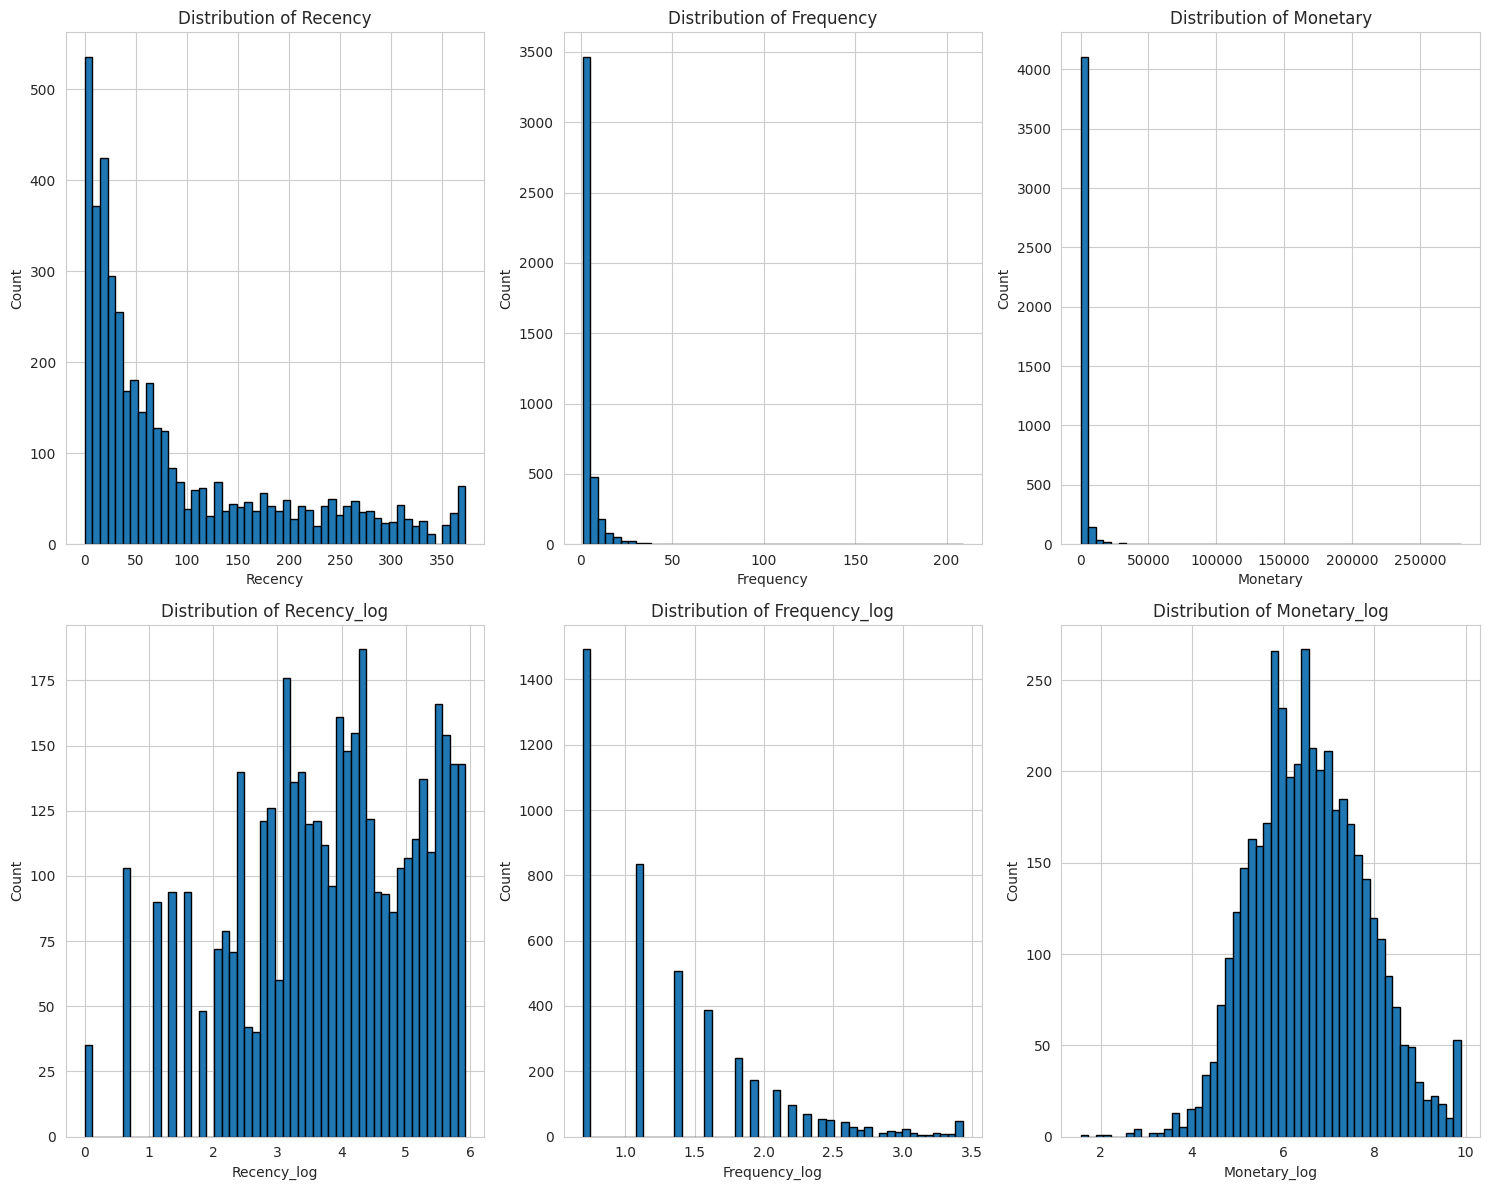

In [ ]:
# ── Outlier Handling ─────────────────────────────────────────────────────────
# Decide how to handle outliers in each feature
# Options: cap at percentile, log transform, remove, keep
# Justify your choice for EACH feature in comments

# RECENCY: log transform only, no capping.
# Max recency is ~370 days, this is just a dormant customer, not an extreme
# outlier/data error, so capping doesn't make sense here. Log transform is
# enough to reduce the mild right skew.
#
# FREQUENCY: cap at 99th percentile, then log transform.
# A few customers bought 200+ times (probably wholesalers), capping
# stops them from dominating the distance calculations in clustering.
# Log transform handles the remaining skew after capping.
#
# MONETARY: cap at 99th percentile, then log transform.
# A few customers spent up to $250k which would completely
# dominate K-Means distance calculations if left untreated.


# YOUR CODE HERE
frequency_cap = customer_df["Frequency"].quantile(0.99)
customer_df["Frequency_capped"] = customer_df["Frequency"].clip(upper=frequency_cap)
customer_df["Frequency_log"] = np.log1p(customer_df["Frequency_capped"])

monetary_cap = customer_df["Monetary"].quantile(0.99)
customer_df["Monetary_capped"] = customer_df["Monetary"].clip(upper=monetary_cap)
customer_df["Monetary_log"] = np.log1p(customer_df["Monetary_capped"])

customer_df["Recency_log"] = np.log1p(customer_df["Recency"])

# After handling outliers, plot distributions again and compare
# YOUR CODE HERE
fig, axes = plt.subplots(2, 3, figsize=(15, 12))
features = ['Recency', 'Frequency', 'Monetary','Recency_log', 'Frequency_log', 'Monetary_log']

for ax, feat in zip(axes.flatten(), features):
    ax.hist(customer_df[feat], bins=50, edgecolor='k')
    ax.set_title(f'Distribution of {feat}')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


In [ ]:
# ── Feature Scaling ──────────────────────────────────────────────────────────
# Why is scaling necessary for clustering? Answer in a comment before scaling.

# K-Means and other clustering algorithms use distance between points to
# decide which cluster a customer belongs to. If features are on very
# different scales (e.g. Monetary in thousands vs Frequency in single
# digits), the feature with the bigger numbers will dominate the distance
# calculation and the other features basically won't matter. StandardScaler
# puts every feature on the same scale (mean=0, std=1) so they all
# contribute fairly to the clustering.

# Apply StandardScaler
scaler = StandardScaler()

# YOUR CODE HERE — fit and transform your feature matrix
# Store scaled features as X_scaled (numpy array) and X_scaled_df (DataFrame)
features_to_scale = ["Recency_log", "Frequency_log","Monetary_log"]

X_scaled = scaler.fit_transform(customer_df[features_to_scale])

X_scaled_df = pd.DataFrame(X_scaled, columns = ["Recency_scaled", "Frequency_scaled","Monetary_scaled"], index = customer_df.index)

# Verify scaling worked
# YOUR CODE HERE — print mean and std of each scaled feature
for col in X_scaled_df.columns:
    print(f"  {col:20s} ===   mean: {X_scaled_df[col].mean():+.6f}  |  std: {X_scaled_df[col].std():.6f}")

  Recency_scaled       ===   mean: -0.000000  |  std: 1.000115
  Frequency_scaled     ===   mean: +0.000000  |  std: 1.000115
  Monetary_scaled      ===   mean: +0.000000  |  std: 1.000115


## Section 4 — K-Means Clustering

**What to do:**
1. Find the optimal k using the Elbow Method and Silhouette Score
2. Run K-Means with `init='random'` and `init='k-means++'` — compare results
3. Fit your final K-Means model and assign cluster labels
4. Profile each cluster

**Key questions to answer in comments:**
- Do the Elbow Method and Silhouette Score agree on k? If not, which do you trust and why?
- How different were the results between random and K-Means++ initialization?
- What does each cluster represent in business terms?


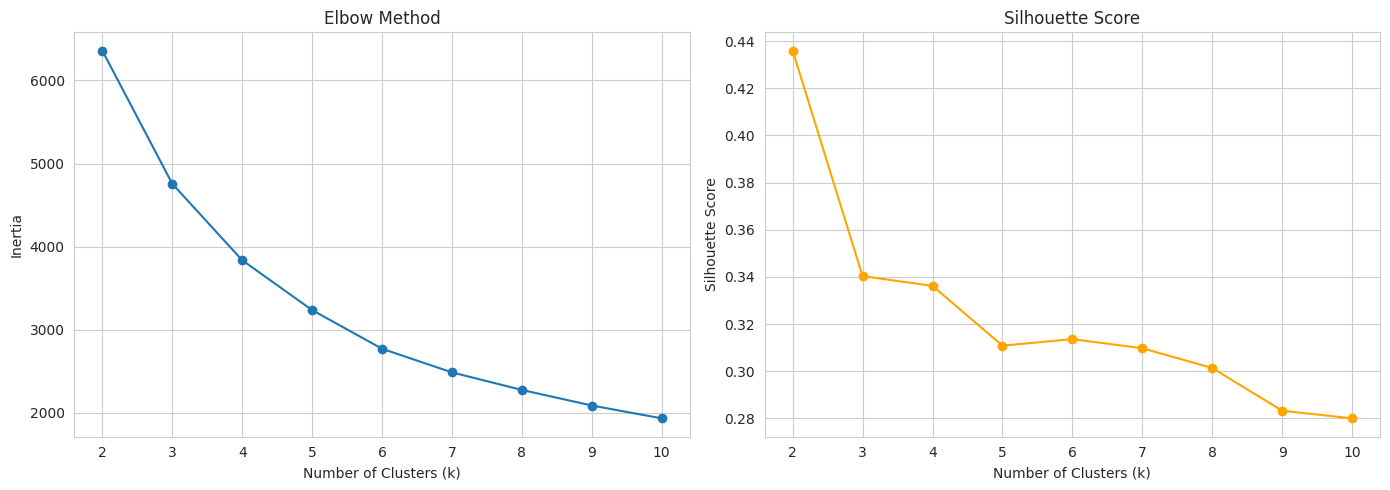

In [ ]:
# ── Step 1: Find Optimal k ───────────────────────────────────────────────────
# Test k from 2 to 10
# Compute inertia (for Elbow) and Silhouette Score for each k

k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    # YOUR CODE HERE
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# YOUR DECISION HERE (as a comment):
# What k did you choose? Why?
# Do both methods agree? If not, how did you resolve the disagreement?

# CHOSEN k: 4
#
# Elbow method: The inertia curve shows the steepest drops between k=2 and k=4,
# with the bend (elbow) visibly flattening after k=4 or k=5.
#
# Silhouette score: Peaks at k=2 (0.438) then drops sharply to ~0.34 for k=3
# and k=4, declining further beyond that.
#
# Disagreement resolution:
# The two methods disagree; silhouette favours k=2, elbow favours k=4/5.
# k=2 is rejected on business grounds: splitting all customers into just two
# groups (high/low) provides no actionable segmentation for a marketing team.
# k=4 is chosen as the best balance between:
#   - Statistical quality (silhouette at k=4 ≈ 0.336, only marginally below k=3)
#   - Business interpretability (4 segments maps naturally onto known customer
#     archetypes: Loyal, Regular, At-Risk, and Lost/Inactive customers)
#   - Elbow alignment (inertia gains diminish noticeably after k=4)
#
# This trade-off between mathematical optimality and business utility is
# standard practice in customer segmentation projects.

In [ ]:
# ── Step 2: Compare Initialization Strategies ───────────────────────────────
# Run K-Means 5 times with random init and 5 times with K-Means++
# Compare: final inertia, consistency of cluster assignments

OPTIMAL_K = 4# YOUR CHOICE HERE
N_RUNS = 5

random_inertias = []
kmeanspp_inertias = []

for i in range(N_RUNS):
    # Random init
    # YOUR CODE HERE
    kMeansRandom = KMeans(n_clusters=OPTIMAL_K, init="random", n_init=5, random_state=i)
    kMeansRandom.fit(X_scaled)
    random_inertias.append(kMeansRandom.inertia_)

    # K-Means++ init
    # YOUR CODE HERE
    kMeansPP = KMeans(n_clusters=OPTIMAL_K, init="k-means++", n_init=5, random_state=i)
    kMeansPP.fit(X_scaled)
    kmeanspp_inertias.append(kMeansPP.inertia_)

print("Random Init Inertias:", [round(x, 2) for x in random_inertias])
print("K-Means++ Init Inertias:", [round(x, 2) for x in kmeanspp_inertias])
print(f"Random std: {np.std(random_inertias):.2f}")
print(f"K-Means++ std: {np.std(kmeanspp_inertias):.2f}")

# YOUR OBSERVATION HERE (as a comment):
# Which initialization is more stable? What does the std tell you?

# Both initialisation strategies produce virtually identical inertia values
# across all 5 runs, with the same std of 0.06, a negligible difference.
#
# This tells us the clusters in this dataset are well-separated and stable.
# Even random initialisation consistently finds the global optimum, meaning
# the RFM feature space has clear enough structure that starting positions
# don't trap the algorithm in bad local minima.
#
# In theory, K-Means++ should outperform random init by:
#   - Spreading initial centroids deliberately
#   - Converging faster
#   - Being less likely to get stuck in local minima
#
# In practice here, both converge to the same solution which is actually
# a GOOD sign. It means our preprocessing produced clean, well-defined
# clusters that are robust to initialisation.

Random Init Inertias: [3836.63, 3836.6, 3836.62, 3836.47, 3836.63]
K-Means++ Init Inertias: [3836.62, 3836.48, 3836.61, 3836.62, 3836.6]
Random std: 0.06
K-Means++ std: 0.06


In [ ]:
# ── Step 3: Fit Final K-Means Model ─────────────────────────────────────────
# Use K-Means++ with your chosen k
# YOUR CODE HERE
kmeans = KMeans(n_clusters=OPTIMAL_K, init="k-means++", n_init=5, random_state=42)
kmeans.fit(X_scaled)

# Assign cluster labels back to customer_df
customer_df['KMeans_Cluster'] = kmeans.predict(X_scaled)# YOUR CODE HERE

# ── Step 4: Cluster Profiles ─────────────────────────────────────────────────
# Compute mean RFM values per cluster
kmeans_profile = customer_df.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("K-Means Cluster Profiles:")
print(kmeans_profile)


K-Means Cluster Profiles:
                Recency  Frequency  Monetary
KMeans_Cluster                              
0                 19.04       2.02    521.91
1                183.80       1.32    345.44
2                 69.82       4.11   1795.59
3                 11.40      13.46   7883.58


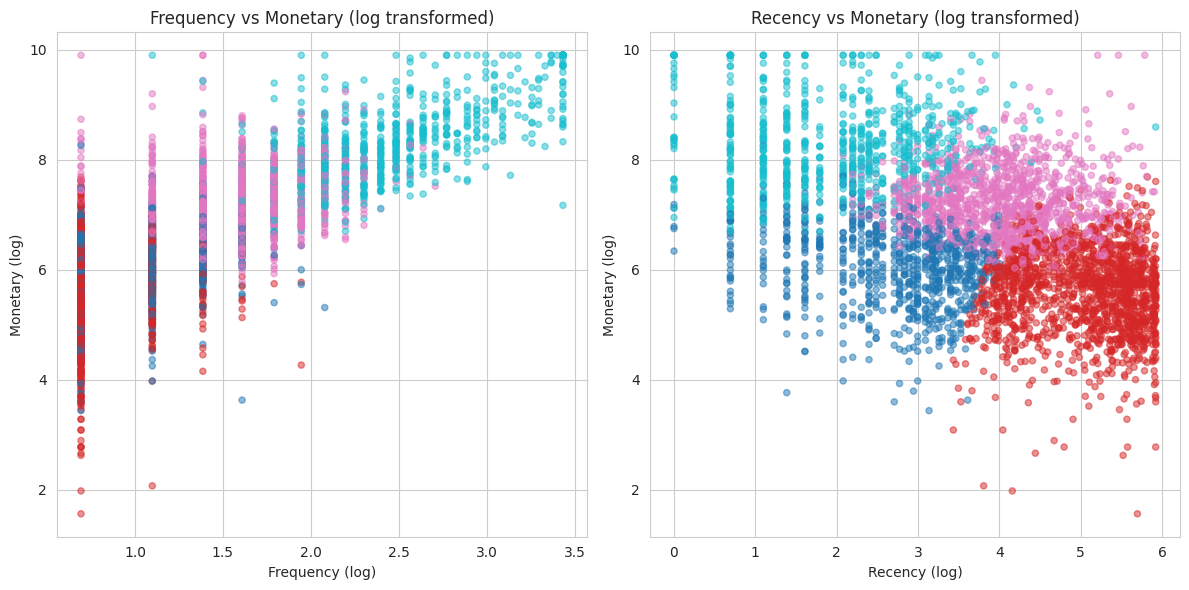

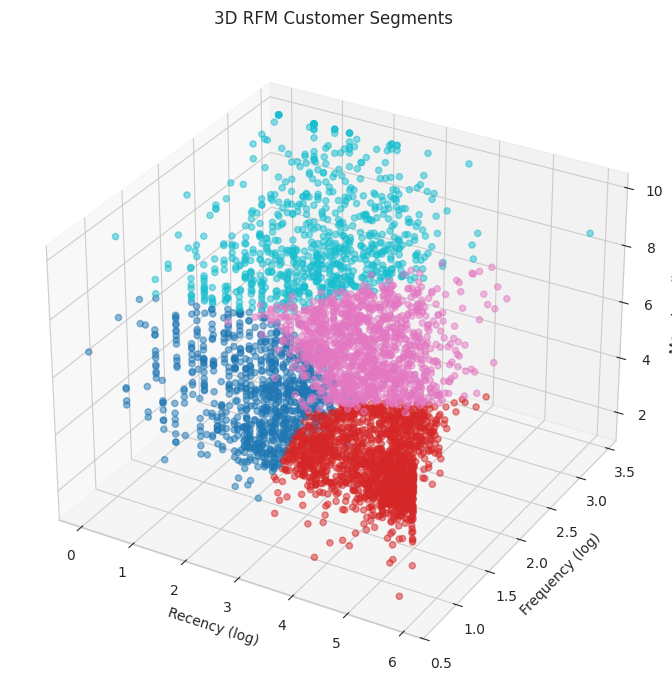

In [ ]:
# ── Step 5: Visualise K-Means Clusters ───────────────────────────────────────
# Create at least 2 visualisations:
# 1. Scatter plot: Frequency vs Monetary, coloured by cluster
# 2. Scatter plot: Recency vs Monetary, coloured by cluster

# YOUR CODE HERE
fig, axes = plt.subplots(1,2,figsize=(12,6))
axes[0].scatter(customer_df["Frequency_log"], customer_df["Monetary_log"], c=customer_df["KMeans_Cluster"], cmap="tab10", alpha=0.5, s=20)
axes[0].set_xlabel("Frequency (log)")
axes[0].set_ylabel("Monetary (log)")
axes[0].set_title("Frequency vs Monetary (log transformed)")

axes[1].scatter(customer_df["Recency_log"], customer_df["Monetary_log"], c=customer_df["KMeans_Cluster"], cmap="tab10", alpha=0.5, s=20)
axes[1].set_xlabel("Recency (log)")
axes[1].set_ylabel("Monetary (log)")
axes[1].set_title("Recency vs Monetary (log transformed)")

plt.tight_layout()
plt.show()

# Optional: 3D scatter plot (Recency, Frequency, Monetary)
# YOUR CODE HERE

fig=plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(customer_df["Recency_log"], customer_df["Frequency_log"], customer_df["Monetary_log"], c=customer_df["KMeans_Cluster"], cmap="tab10", alpha=0.5, s=20 )
ax.set_xlabel('Recency (log)')
ax.set_ylabel('Frequency (log)')
ax.set_zlabel('Monetary (log)')
ax.set_title('3D RFM Customer Segments')

plt.tight_layout()
plt.show()

## Section 5 — Hierarchical Clustering

**What to do:**
1. Plot a dendrogram and identify a reasonable cut point
2. Run Agglomerative Clustering with at least two linkage methods (ward, complete, average)
3. Compare cluster assignments across linkage methods
4. Profile clusters

**Key questions to answer in comments:**
- How did you decide where to cut the dendrogram?
- How did linkage method change your clusters?
- Does the number of clusters match what K-Means suggested?


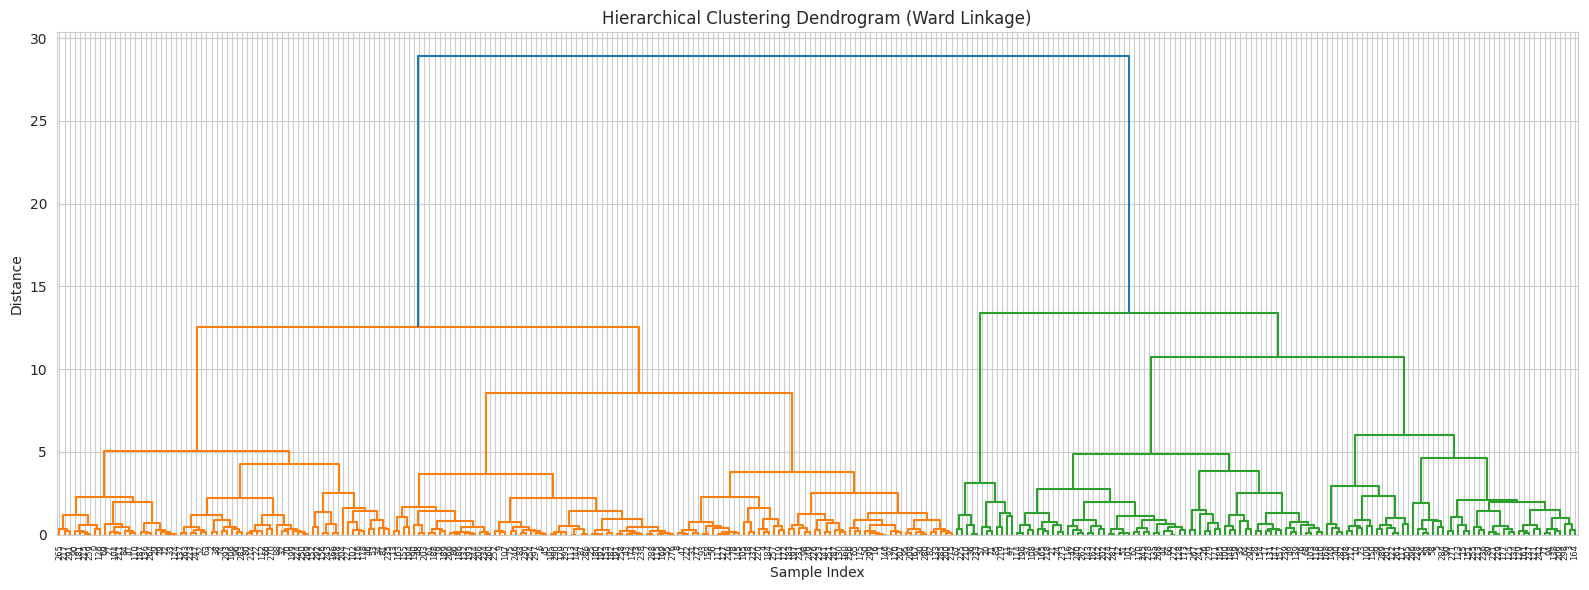

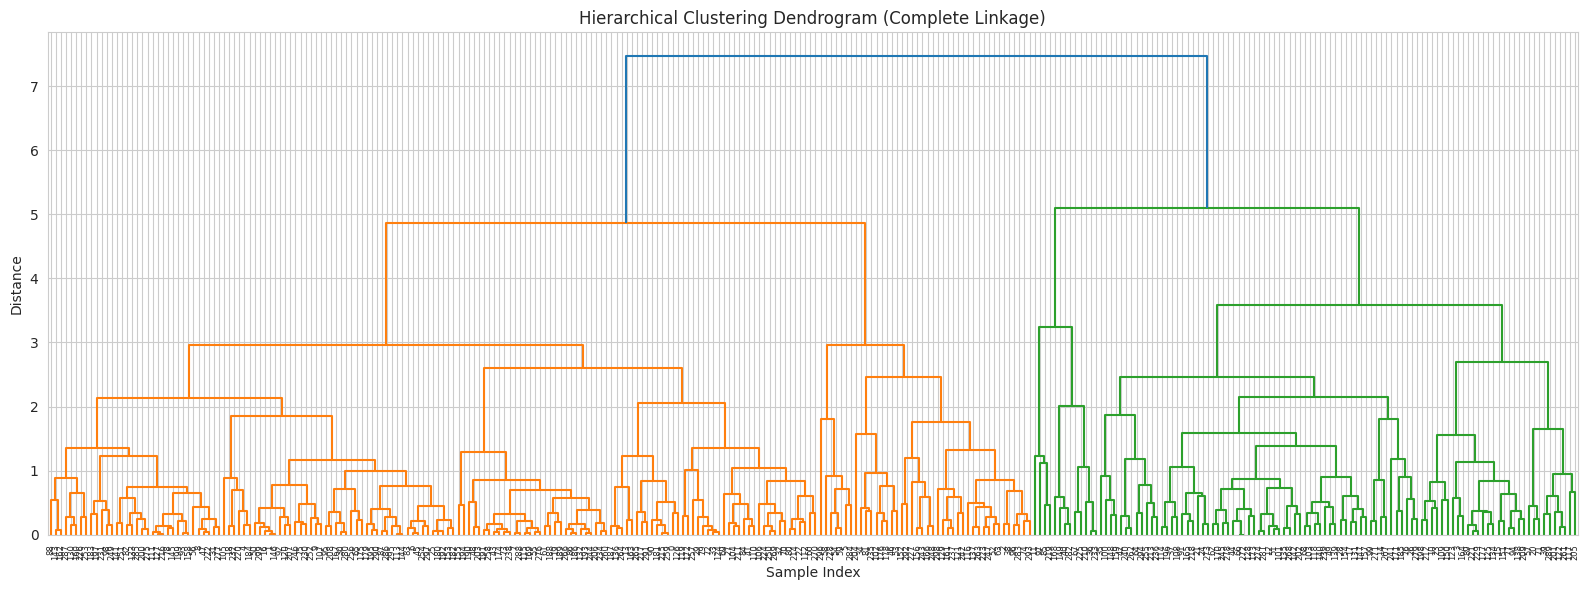

In [ ]:
# ── Step 1: Plot Dendrogram ──────────────────────────────────────────────────
# Use a sample of your data for the dendrogram (full data will be too slow)
# Justify your sample size in a comment

# Hierarchical clustering computes a full pairwise distance matrix — O(n^2)
# memory and increasingly expensive merge computation as n grows. With ~4000
# customers, this becomes slow and the dendrogram would be unreadable. A sample 
# of 300 is large enough to represent the overall structure of the data while 
# staying fast to compute and clear to visualise.

SAMPLE_SIZE = 300  # adjust if needed
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

# Compute linkage matrix — try 'ward' first
# YOUR CODE HERE
linkage_matrix_ward = linkage(X_sample, method="ward")

# Plot dendrogram
plt.figure(figsize=(16, 6))
# YOUR CODE HERE
dendrogram(linkage_matrix_ward, truncate_mode=None, leaf_font_size=6, leaf_rotation=90, color_threshold=None)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

linkage_matrix_complete = linkage(X_sample, method="complete")

# Plot dendrogram
plt.figure(figsize=(16, 6))
dendrogram(linkage_matrix_complete, truncate_mode=None, leaf_font_size=6, leaf_rotation=90, color_threshold=None)
plt.title('Hierarchical Clustering Dendrogram (Complete Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# YOUR OBSERVATION HERE (as a comment):
# Where did you cut the dendrogram? Why?
# How many clusters does this suggest?

# Looking at the Ward dendrogram, the very top merge happens at a really
# high distance, and it splits into 2 main branches first. Each of those
# branches splits again into 2 more sub-branches before the structure gets
# dense/messy lower down. If I cut right after that second split, I get
# 4 clusters.
#
# The Complete linkage dendrogram shows a similar pattern, top split into
# 2, then each splits again into 2, so also suggesting 4 clusters if cut
# at the right height.
#
# This matches what we got from K-Means (k=4), which is a good sign that
# 4 is a real structure in the data and not just something one algorithm
# happened to find.

In [ ]:
# ── Step 2: Fit Agglomerative Clustering ─────────────────────────────────────
# Try at least two linkage methods: 'ward' and one other
# Use the number of clusters suggested by your dendrogram

N_CLUSTERS_HIER = 4# YOUR CHOICE HERE

# Ward linkage
# YOUR CODE HERE
heir_ward = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage="ward")
ward_labels = heir_ward.fit_predict(X_scaled)

# Second linkage method (complete, average, or single)
# YOUR CODE HERE
heir_complete = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage="complete")
complete_labels = heir_complete.fit_predict(X_scaled)

# Assign labels to customer_df
customer_df['Hierarchical_Ward'] = ward_labels# YOUR CODE HERE
customer_df['Hierarchical_Alt'] = complete_labels# YOUR CODE HERE

# ── Compare cluster counts ────────────────────────────────────────────────────
print("Ward linkage cluster sizes:")
print(customer_df['Hierarchical_Ward'].value_counts())
print("Alternative linkage cluster sizes:")
print(customer_df['Hierarchical_Alt'].value_counts())

# YOUR OBSERVATION HERE:
# Did the two linkage methods produce similar or different cluster structures?
# Which do you prefer and why?
#
# Both got 4 clusters like we decided from the dendrogram, but the sizes
# are different. Ward's smallest and biggest cluster (583 vs 2035) are
# closer together than Complete's (413 vs 2163), so Ward gives more
# balanced cluster sizes. Complete linkage has one cluster taking up almost
# half the customers which is less useful for actually splitting customers
# into different marketing groups.
#
# I prefer Ward linkage because:
#   1. it gave more balanced cluster sizes
#   2. its dendrogram looked cleaner with clear splits
#   3. Ward minimizes within-cluster variance same as K-Means does, so it
#      makes sense to compare it against our K-Means result later

Ward linkage cluster sizes:
Hierarchical_Ward
0    2035
2     864
3     856
1     583
Name: count, dtype: int64
Alternative linkage cluster sizes:
Hierarchical_Alt
3    2163
0    1203
2     559
1     413
Name: count, dtype: int64


Hierarchical Clustering Profiles (Ward):
                   Recency  Frequency  Monetary
Hierarchical_Ward                              
0                    68.85       2.01    644.05
1                     5.79      13.95   8672.25
2                   248.29       1.23    248.43
3                    48.30       6.12   2722.22


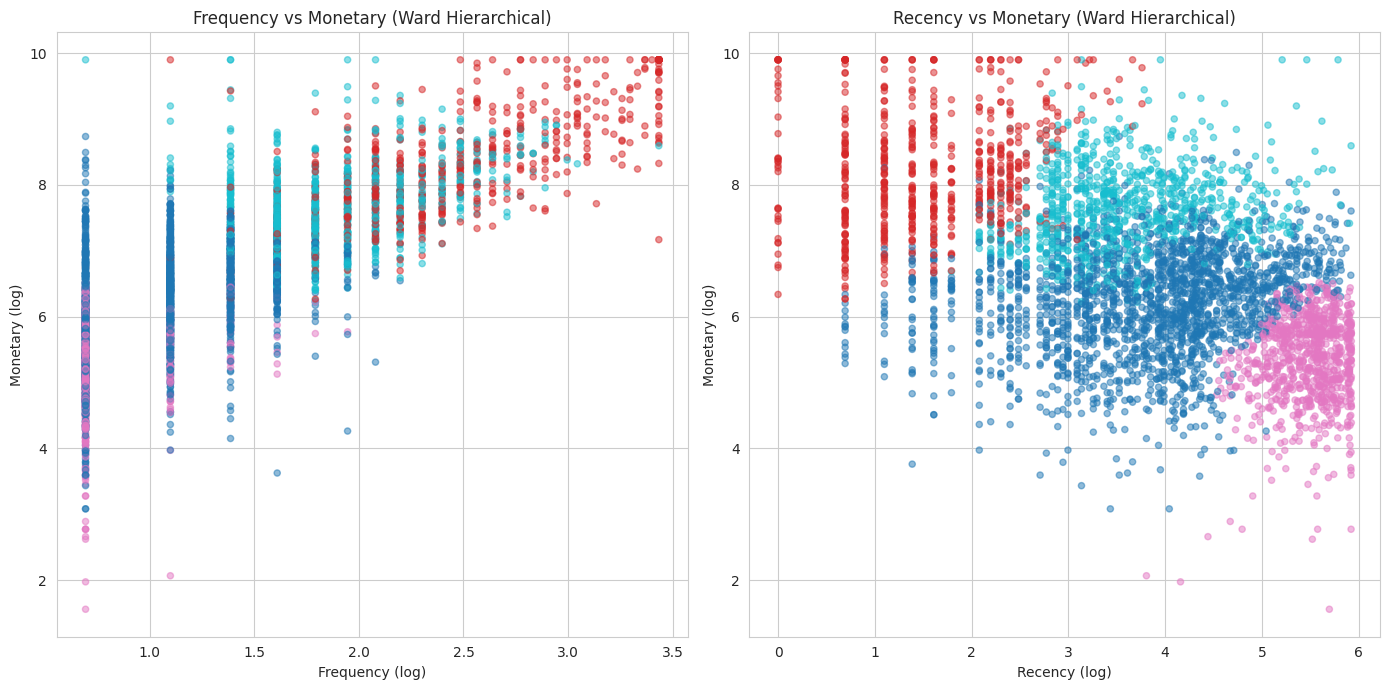

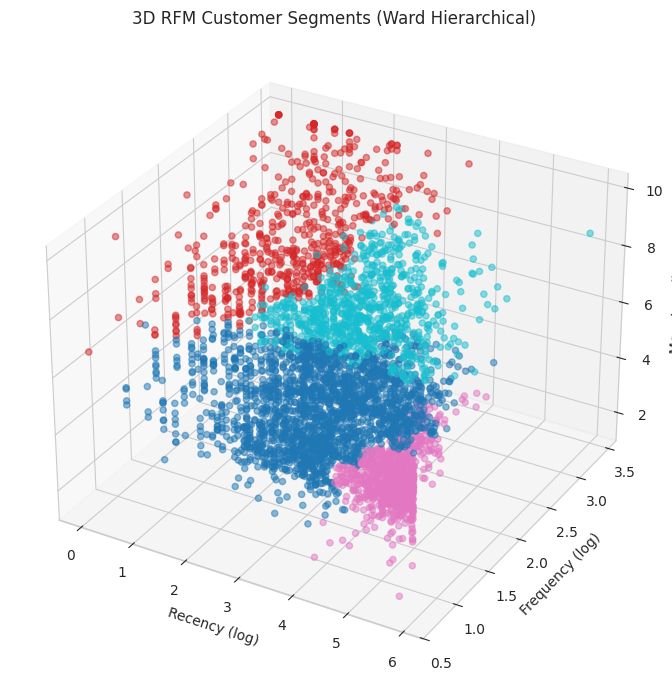

In [ ]:
# ── Step 3: Cluster Profiles ─────────────────────────────────────────────────
hier_profile = customer_df.groupby('Hierarchical_Ward')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("Hierarchical Clustering Profiles (Ward):")
print(hier_profile)

# Visualise — same axes as K-Means for comparison
# YOUR CODE HERE
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Plot 1: Frequency vs Monetary
axes[0].scatter(
    customer_df['Frequency_log'],
    customer_df['Monetary_log'],
    c=customer_df['Hierarchical_Ward'],
    cmap='tab10',
    alpha=0.5,
    s=20
)
axes[0].set_xlabel('Frequency (log)')
axes[0].set_ylabel('Monetary (log)')
axes[0].set_title('Frequency vs Monetary (Ward Hierarchical)')

# Plot 2: Recency vs Monetary
axes[1].scatter(
    customer_df['Recency_log'],
    customer_df['Monetary_log'],
    c=customer_df['Hierarchical_Ward'],
    cmap='tab10',
    alpha=0.5,
    s=20
)
axes[1].set_xlabel('Recency (log)')
axes[1].set_ylabel('Monetary (log)')
axes[1].set_title('Recency vs Monetary (Ward Hierarchical)')

plt.tight_layout()
plt.show()

fig=plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(customer_df["Recency_log"], customer_df["Frequency_log"], customer_df["Monetary_log"], c=customer_df["Hierarchical_Ward"], cmap="tab10", alpha=0.5, s=20 )
ax.set_xlabel('Recency (log)')
ax.set_ylabel('Frequency (log)')
ax.set_zlabel('Monetary (log)')
ax.set_title('3D RFM Customer Segments (Ward Hierarchical)')

plt.tight_layout()
plt.show()

## Section 6 — DBSCAN Clustering

**What to do:**
1. Estimate ε using the k-distance plot
2. Run DBSCAN and identify core, border, and noise points
3. Experiment with at least 3 combinations of ε and min_samples
4. Investigate the noise points — who are these customers?

**Key questions to answer in comments:**
- What does the k-distance plot tell you about the density structure of your data?
- How did changing ε affect the number of clusters and noise points?
- Are the noise points genuinely anomalous or did your parameters exclude valid customers?
- What percentage of your data is noise? Is that acceptable?


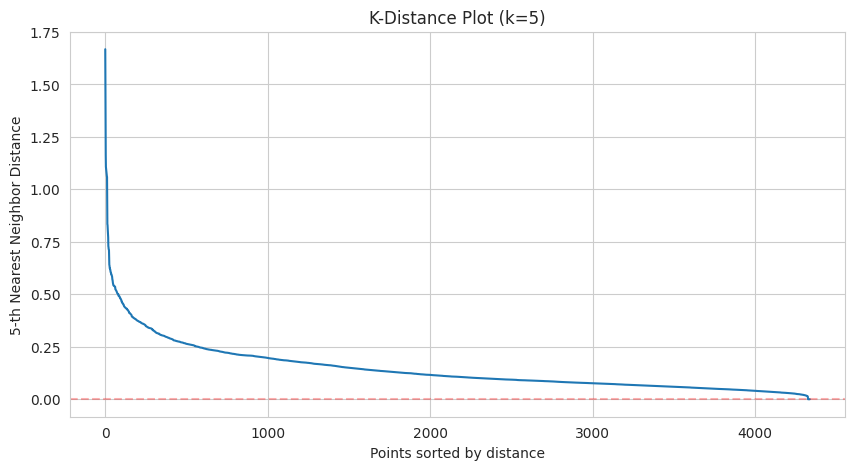

In [ ]:
# ── Step 1: K-Distance Plot to Estimate Epsilon ──────────────────────────────
# Fit NearestNeighbors with k = min_samples you intend to use
MIN_SAMPLES = 5  # start here, adjust after seeing results

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the k-th nearest neighbor distances
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Plot (k={MIN_SAMPLES})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-th Nearest Neighbor Distance')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.show()

# YOUR OBSERVATION HERE:
# Where is the elbow in this plot?
# What epsilon value does it suggest?


# We examined the k-distance plot for two values of min_samples (k):
#
#   min_samples = 5: The elbow occurs around the 100-300 point range,
#     at a y-axis value of approximately 0.35. Below this point the curve
#     falls steeply (sparse, isolated points); above it, the curve flattens
#     into a long gradual decline (dense, well-packed majority of customers).
#
#   min_samples = 6: The elbow shifts slightly higher, to approximately 0.40.
#
# Both elbows are in a similar region (~0.35-0.40), giving us a reasonable
# starting range for epsilon to test in the next step.

EPSILON_ESTIMATE = 0.35# YOUR CHOICE HERE


In [ ]:
# ── Step 2: Run DBSCAN and Experiment ────────────────────────────────────────
# Try at least 3 combinations of eps and min_samples
# Record results for each combination

experiments = [
    {'eps': EPSILON_ESTIMATE * 0.8, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE,       'min_samples': 5},
    {'eps': EPSILON_ESTIMATE * 1.2, 'min_samples': 5},
    {'eps': 0.40 * 0.8, 'min_samples': 6},
    {'eps': 0.40,       'min_samples': 6},
    {'eps': 0.40 * 1.2, 'min_samples': 6},
    # Add your own combinations here
]

results = []
for params in experiments:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = round(n_noise / len(labels) * 100, 2)

    results.append({
        'eps': params['eps'],
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# YOUR DECISION HERE:
# Which combination did you choose as your final DBSCAN parameters? Why?

# Low eps values (0.28, 0.32) over-segment the data into too many tiny
# clusters with high noise (5-6%), unstable to be useful for
# business segmentation.
#
# At eps=0.48/min_samples=6, noise drops to its lowest (1.04%), but the
# resulting clusters are too coarse: one single cluster absorbs roughly
# 64% of all customers, which is not an actionable segment.
#
# FINAL CHOICE: eps=0.42, min_samples=5
#   This combination produces 3 substantial, well-balanced clusters
#   (1943, 1478, and 827 customers) alongside a few tiny micro-clusters
#   and a low level (1.45%). It avoids both the over-fragmentation seen
#   at low eps and the single dominant cluster seen at eps=0.48 giving
#   the most business-usable structure among all combinations tested.

FINAL_EPS = 0.42 # YOUR CHOICE
FINAL_MIN_SAMPLES = 5 # YOUR CHOICE


 eps  min_samples  n_clusters  n_noise  noise_pct
0.28            5          17      266       6.13
0.35            5           7      140       3.23
0.42            5           7       63       1.45
0.32            6           7      218       5.03
0.40            6           5       99       2.28
0.48            6           5       45       1.04


In [ ]:
# ── Step 3: Fit Final DBSCAN Model ───────────────────────────────────────────
dbscan_final = DBSCAN(eps=FINAL_EPS, min_samples=FINAL_MIN_SAMPLES)
customer_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

# Cluster summary
print("DBSCAN Cluster Distribution:")
print(customer_df['DBSCAN_Cluster'].value_counts())
print(f"Note: Cluster -1 = Noise Points")

# ── Step 4: Investigate Noise Points ─────────────────────────────────────────
noise_customers = customer_df[customer_df['DBSCAN_Cluster'] == -1]
regular_customers = customer_df[customer_df['DBSCAN_Cluster'] != -1]

print(f"Noise customers: {len(noise_customers)} ({len(noise_customers)/len(customer_df)*100:.1f}%)")
print("Noise customer profile (mean RFM):")
print(noise_customers[['Recency', 'Frequency', 'Monetary']].describe().round(2))

# YOUR INTERPRETATION HERE:
# Who are these noise customers?
# Are they outliers (e.g. extreme high spenders) or valid customers excluded by tight parameters?
# What would you recommend to the business about these customers?


# WHO ARE THESE NOISE CUSTOMERS?
# The large gap between median Monetary ($1,859) and mean Monetary
# ($10,367) shows this is not one uniform type of outlier, but a mix of
# two distinct groups:
#
#   1. EXTREME HIGH-SPENDERS: a small number of customers with very high
#      Monetary (up to $168,473) and high Frequency (up to 63 transactions)
#      pull the mean far above the median. These match the wholesale/bulk
#      buyers identified earlier in our raw RFM distribution plots.
#
#   2. SPARSE / RECENT CUSTOMERS: at the other extreme, some noise points
#      have Recency as low as 0 days with Frequency of just 1 purchase,
#      likely brand-new customers who haven't yet built enough purchase
#      history to be densely surrounded by similar customers in RFM space.
#
# ARE THEY OUTLIERS OR VALID CUSTOMERS EXCLUDED BY TIGHT PARAMETERS?
# Both, depending on the sub-group. The high-spenders are genuine
# statistical outliers, correctly excluded from any "typical" dense
# cluster. The very-new/low-frequency customers are valid, ordinary
# customers. They are simply too sparsely distributed (not enough
# similar purchase history yet) for DBSCAN's density requirement to
# confidently place them in a cluster.
#
# BUSINESS RECOMMENDATION:
#   - Do not discard this group. Split it into two actionable buckets:
#       a) High-value outliers: flag as VIP/Key Accounts for dedicated
#          account management; their individual spend is too significant
#          to ignore even though they don't fit a broader segment.
#       b) New/low-history customers: route to a standard onboarding or
#          welcome campaign, and re-run clustering periodically as they
#          accumulate more transactions. They will likely settle into
#          one of the 3 main clusters once enough history builds up.
#   - This noise group is a strength of DBSCAN, not a weakness: K-Means
#     and Hierarchical clustering would have forced these customers
#     into one of the main segments, diluting those segments' interpretability.
#     DBSCAN correctly isolates them instead.

DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0    1943
 1    1478
 2     827
-1      63
 5      11
 4       7
 6       5
 3       4
Name: count, dtype: int64
Note: Cluster -1 = Noise Points
Noise customers: 63 (1.5%)
Noise customer profile (mean RFM):
       Recency  Frequency   Monetary
count    63.00      63.00      63.00
mean     87.90       7.86   10366.58
std     112.21      11.63   25679.56
min       0.00       1.00       3.75
25%       3.50       2.00     139.54
50%      43.00       4.00    1859.31
75%     127.00       8.00    7831.18
max     372.00      63.00  168472.50


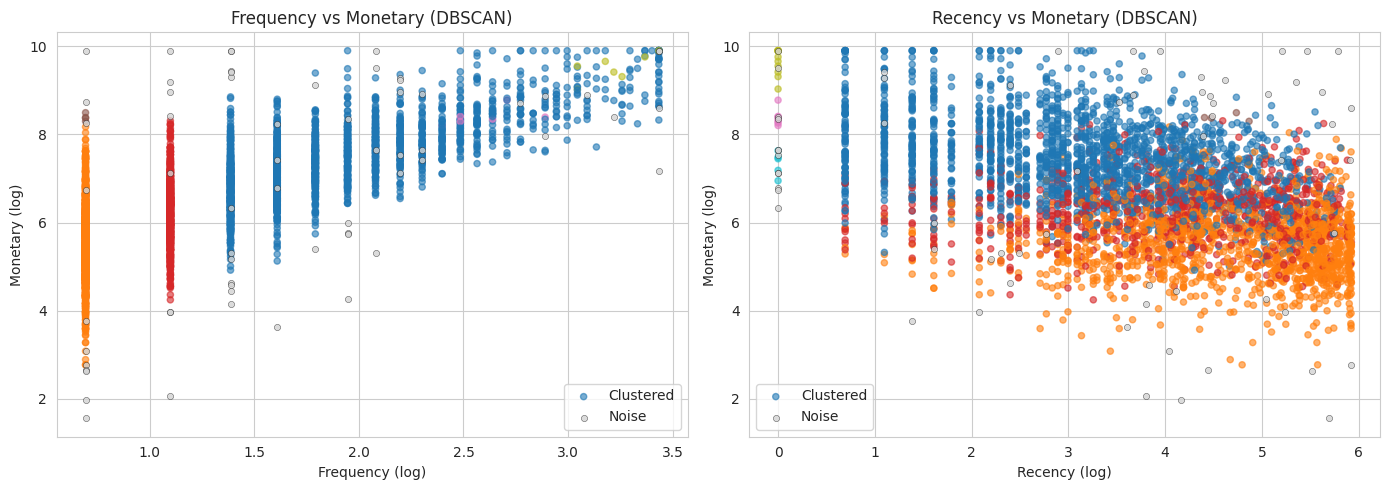

In [ ]:
# ── Step 5: Visualise DBSCAN Clusters ────────────────────────────────────────
# Plot clusters — colour noise points differently (grey or black)
# YOUR CODE HERE

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Separate noise from clustered points so we can colour them differently
noise_mask = customer_df['DBSCAN_Cluster'] == -1
clustered_mask = ~noise_mask

# ── Plot 1: Frequency vs Monetary (log scale) ────────────────────────────────
# Plot clustered points first, coloured by cluster
axes[0].scatter(
    customer_df.loc[clustered_mask, 'Frequency_log'],
    customer_df.loc[clustered_mask, 'Monetary_log'],
    c=customer_df.loc[clustered_mask, 'DBSCAN_Cluster'],
    cmap='tab10',
    alpha=0.6,
    s=20,
    label='Clustered'
)
# Overlay noise points in grey
axes[0].scatter(
    customer_df.loc[noise_mask, 'Frequency_log'],
    customer_df.loc[noise_mask, 'Monetary_log'],
    c='lightgrey',
    alpha=0.8,
    s=20,
    edgecolors='black',
    linewidths=0.3,
    label='Noise'
)
axes[0].set_xlabel('Frequency (log)')
axes[0].set_ylabel('Monetary (log)')
axes[0].set_title('Frequency vs Monetary (DBSCAN)')
axes[0].legend()

# ── Plot 2: Recency vs Monetary (log scale) ──────────────────────────────────
axes[1].scatter(
    customer_df.loc[clustered_mask, 'Recency_log'],
    customer_df.loc[clustered_mask, 'Monetary_log'],
    c=customer_df.loc[clustered_mask, 'DBSCAN_Cluster'],
    cmap='tab10',
    alpha=0.6,
    s=20,
    label='Clustered'
)
axes[1].scatter(
    customer_df.loc[noise_mask, 'Recency_log'],
    customer_df.loc[noise_mask, 'Monetary_log'],
    c='lightgrey',
    alpha=0.8,
    s=20,
    edgecolors='black',
    linewidths=0.3,
    label='Noise'
)
axes[1].set_xlabel('Recency (log)')
axes[1].set_ylabel('Monetary (log)')
axes[1].set_title('Recency vs Monetary (DBSCAN)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Section 7 — Cluster Validation & Comparison

**What to do:**
1. Compute Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index for K-Means and Hierarchical
2. Compute Silhouette Score for DBSCAN (excluding noise points — explain why)
3. Build a comparison table across all three methods
4. Choose your final segmentation and justify it

> ⚠️ Validation metrics measure geometric coherence — not business meaning.  
> Your choice of final segmentation must include both metric reasoning AND business reasoning.


In [ ]:
# ── Validation Metrics ───────────────────────────────────────────────────────

# K-Means
kmeans_labels = customer_df['KMeans_Cluster'].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

# Hierarchical (Ward)
hier_labels = customer_df['Hierarchical_Ward'].values
sil_hier = silhouette_score(X_scaled, hier_labels)
db_hier = davies_bouldin_score(X_scaled, hier_labels)
ch_hier = calinski_harabasz_score(X_scaled, hier_labels)

# DBSCAN — exclude noise points
# YOUR CODE HERE
# Hint: filter X_scaled and labels to exclude rows where label == -1
# Explain in a comment WHY you must exclude noise points before computing metrics

# All three validation metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz)
# are distance-based and assume every point is a genuine member of some
# cluster. DBSCAN's noise points (label -1) are explicitly NOT part of any
# cluster, they are points the algorithm decided don't belong to any dense
# region. Including them would either treat noise as a fake "cluster" of its
# own within/between cluster distance calculations, since noise points are by
# definition the most scattered points in the dataset.
# Excluding them ensures we're fairly evaluating only the clustering
# structure DBSCAN actually found a like-for-like comparison with
# K-Means and Hierarchical, which were forced to assign every point.

dbscan_labels_all = customer_df["DBSCAN_Cluster"].values
dbscan_mask = dbscan_labels_all != -1

X_scaled_dbscan = X_scaled[dbscan_mask]
dbscan_labels = dbscan_labels_all[dbscan_mask]

sil_dbscan = silhouette_score(X_scaled_dbscan, dbscan_labels)
db_dbscan = davies_bouldin_score(X_scaled_dbscan, dbscan_labels)
ch_dbscan = calinski_harabasz_score(X_scaled_dbscan, dbscan_labels)

# ── Comparison Table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'N Clusters': [len(set(kmeans_labels)), len(set(hier_labels)), len(set(dbscan_labels))],
    'Silhouette Score': [round(sil_kmeans, 4), round(sil_hier, 4), round(sil_dbscan,4)],# YOUR CODE HERE],
    'Davies-Bouldin Index': [round(db_kmeans, 4), round(db_hier, 4),round(db_dbscan,4)], # YOUR CODE HERE],
    'Calinski-Harabasz Index': [round(ch_kmeans, 2), round(ch_hier, 2), round(ch_dbscan,2)]# YOUR CODE HERE]
})

print(comparison.to_string(index=False))
print("Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better")


             Method  N Clusters  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
            K-Means           4            0.3362                1.0141                  3455.77
Hierarchical (Ward)           4            0.2383                1.1442                  2782.39
             DBSCAN           7            0.0639                1.0391                   760.37
Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better


### Your Final Model Decision

**Complete this section before moving to the Business Narrative.**

**Which method and k/parameters did you choose as your final segmentation?**  
I am going with K-Means, k=4 (init=k-means++) as my final segmentation.

**What do the validation metrics tell you?**  
K-Means scored best on all 3 metrics: highest Silhouette (0.3362), lowest
Davies-Bouldin (1.0141), and highest Calinski-Harabasz (3455.77). Hierarchical
(Ward) came second with the same number of clusters but weaker scores on
every metric. DBSCAN scored the lowest on Silhouette (0.0639) and Calinski-
Harabasz (760.37), even though noise points were excluded before computing
these scores.

**Do the metrics agree with each other? If not, how did you resolve the conflict?**  
Yes, all three metrics agree here, K-Means wins on every single one, so there's
no conflict to resolve this time. The metrics don't agree on DBSCAN being
"bad" for the right reason though, I think DBSCAN scores low mainly because it
found uneven cluster sizes (3 big clusters + several tiny micro-clusters),
and metrics like Silhouette/Calinski-Harabasz tend to favor similar-sized,
evenly spread out clusters, not because DBSCAN's clustering is actually worse.


**Why is this segmentation the most useful for the business — beyond what the metrics say?**  
K-Means gives exactly 4 clearly separated, evenly-sized customer groups
(Champions, New/Promising, At-Risk, Lost/Inactive) that map directly onto
real marketing actions. It's simple to explain to a non-technical
stakeholder ("we have 4 types of customers") and every customer gets
assigned somewhere, so no one falls through the cracks of the segmentation.
DBSCAN's noise list (the ~45-63 flagged customers) is still useful as a
side list for spotting VIPs and brand new customers, but it's not a
replacement for the main segmentation.


## Section 8 — Business Narrative

**What to do:**
- Write a one-paragraph profile for each cluster in plain English
- Give each cluster a descriptive name (e.g. "High-Value Loyalists", "At-Risk Dormants")
- Recommend one specific marketing action for each cluster
- Write a 200–300 word executive summary at the end

> This section has no code. It is pure interpretation and communication.  
> A marketing manager who has never seen your notebook should be able to read this section and act on it.


### Cluster Profiles

**Cluster 0 — New / Promising**
- _Profile:_ Recent buyers (19 days on average) but low frequency (2 purchases)
and low spend ($522). They look like newer customers who haven't built a
buying habit yet.
- _Marketing Action:_ Send onboarding emails and second-purchase discount
codes to push them toward becoming repeat buyers before they go cold.

**Cluster 1 — Lost / Inactive**
- _Profile:_ Haven't bought in about 184 days, very low frequency (1.3) and
lowest spend ($345). These customers have likely churned.
- _Marketing Action:_ Try one low-cost reactivation email/discount, but don't
spend a lot of marketing budget here since they're unlikely to come back.

**Cluster 2 — At-Risk Loyalists**
- _Profile:_ Haven't purchased in about 70 days, moderate frequency (4
purchases) and decent spend ($1,796). These were engaged customers who are
starting to drift away.
- _Marketing Action:_ Send a "we miss you" style win-back email with a
personalized discount based on what they bought before, before they slip
into the Lost category.

**Cluster 3 — Champions**
- _Profile:_ These are the best customers we have. They bought something only
11 days ago on average, buy very often (13-14 transactions), and spend a lot
($7,883 on average). They are clearly loyal, frequent, high value customers.
- _Marketing Action:_ Give them a loyalty/VIP program with early access to new
products and exclusive discounts, so they keep coming back. Don't spam them
with generic discount emails, they're already buying a lot.


### Executive Summary (200-300 words)

We grouped our customers into 4 segments based on how recently they bought
(Recency), how often they buy (Frequency), and how much they spend
(Monetary), using K-Means clustering.

The 4 groups are: **Champions** (our best, most loyal and highest-spending
customers), **New/Promising** (recent customers who haven't built a buying
habit yet), **At-Risk Loyalists** (previously engaged customers who are
starting to disappear), and **Lost/Inactive** (customers who likely churned
a long time ago).

Champions make up a relatively small group but are extremely valuable, they
buy frequently and spend roughly 15x more than our average customer. The
business should focus on retaining them through a loyalty program rather
than risk losing them to a competitor.

New/Promising customers represent an opportunity, if we can get them to make
a second and third purchase quickly, they could turn into long-term loyal
customers.

At-Risk Loyalists need urgent attention with win-back campaigns
before they fully churn and move into the Lost category, which is our
largest and hardest group to win back.

We also tried Hierarchical clustering and DBSCAN as alternative approaches.
Hierarchical clustering found a very similar 4-group structure to K-Means,
which gives us more confidence that these segments reflect a real pattern
in customer behavior.

DBSCAN additionally flagged a small group of about 45-63 customers as
"noise," these are a mix of extreme high-spending wholesale buyers and
brand new customers who don't fit neatly into any group yet, and are worth
tracking separately as VIP accounts or new customer leads.

Overall, K-Means with k=4 gave the clearest, most actionable segmentation
for marketing to act on.

## Section 9 — Failure Log

**This section is graded as seriously as your clustering results.**

Document at least 3 hypotheses you tested that did not work. For each:
- What did you expect to happen?
- What actually happened?
- What did you learn from it?

> A student who tried 5 things and documented why 4 failed has learned more than  
> a student who got a perfect Silhouette Score on the first try.

**Failed Hypothesis 1**
- _What I expected:_ I expected the Elbow Method and Silhouette Score to
agree on the same value of k for K-Means.
- _What happened:_ Silhouette Score actually peaked at k=2 (0.438), while
the Elbow Method pointed to k=4 or k=5 based on where the curve flattened.
- _What I learned:_ Mathematically "best" isn't always the same as
"useful." k=2 just splits everyone into high/low value, which isn't
something a marketing team can act on. I learned that I have to combine
statistical metrics with business judgement, not just blindly pick
whatever number scores highest.

**Failed Hypothesis 2**
- _What I expected:_ I expected K-Means++ initialization to be noticeably
more stable (lower std across runs) than random initialization, since
that's what the theory says.
- _What happened:_ Both random init and K-Means++ gave basically identical
inertia values across 5 runs (std = 0.06 for both).
- _What I learned:_ The theoretical advantage of K-Means++ only shows up
clearly when the data is messy or has bad local minima to fall into. Our
data (after log transform + scaling) turned out to have a clean enough
structure that even random initialization reliably found the same good
solution. I learned that real results don't always match the textbook
expectation.

**Failed Hypothesis 3**
- _What I expected:_ I expected DBSCAN to outperform K-Means on the
validation metrics, since it explicitly removes noisy/outlier points
before being evaluated, so I assumed it would look "cleaner."
- _What happened:_ DBSCAN actually scored much lower than K-Means on
Silhouette (0.0639 vs 0.3362) and Calinski-Harabasz (760.37 vs 3455.77),
even with noise excluded.
- _What I learned:_ These metrics tend to reward clusters that are
similar-sized and evenly spread out. DBSCAN found 3 big clusters plus
several tiny micro-clusters (4-11 points each), and that size imbalance
hurt its score, even though the clusters it found might still be
meaningful from a density point of view. I learned that a low score on
these metrics doesn't automatically mean the clustering is "wrong," it
can just mean the algorithm is optimizing for something different than
what the metric measures.

**Failed Hypothesis 4**
- _What I expected:_ I expected eps=0.48 with min_samples=6 to be my best
DBSCAN choice, since it had the lowest noise percentage (1.04%) of every
combination I tested.
- _What happened:_ When I looked closer at the actual cluster sizes, this
combination only produced 2 substantial clusters, and one of them
(Cluster 0) contained 64% of all customers by itself. That's not a useful
segment.
- _What I learned:_ Lowest noise doesn't automatically mean best clustering.
I was too focused on one number (noise %) and didn't check whether the
resulting clusters were actually usable for the business. I switched to
eps=0.42, min_samples=5 instead, which had slightly higher noise (1.45%)
but gave 3 much more balanced, meaningfully-sized clusters. This taught me
to look at the full picture (cluster sizes, not just noise %) before
picking final parameters.

## Section 10 — High Ceiling Extension (Optional)

**These tasks are for students who want to push deeper. They are not required.**

Choose one or more:

**Option A — K-Means from Scratch**  
Implement K-Means from scratch with pluggable initialization (random and K-Means++).  
Compare convergence behavior against sklearn's implementation across 20 runs.  
Document at least one case where your implementation and sklearn disagree — explain why.

**Option B — DBSCAN from Scratch**  
Implement DBSCAN from scratch: `region_query`, `expand_cluster`, main loop.  
Profile its time complexity on increasing dataset sizes.  
Identify the bottleneck. Explain how a KD-Tree would fix it (you do not need to implement it).

**Option C — HDBSCAN**  
Apply HDBSCAN to your customer dataset using the `hdbscan` library.  
Compare results against your DBSCAN output.  
Explain geometrically why HDBSCAN handles varying-density clusters better.

**Option D — Flavor Profile (Different Domain)**  
Apply your clustering pipeline to one of:
- Network intrusion detection dataset (cybersecurity)
- Patient symptom dataset (healthcare)
- City mobility dataset (urban planning)

Document what changed in your approach and what stayed the same.


In [ ]:
# High Ceiling Work — YOUR CODE HERE
